# Dataset

Use the Pima Indians Diabetes Dataset.

Dataset link:
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

The dataset contains medical information such as:

Pregnancies

Glucose

Blood Pressure

Skin Thickness

Insulin

BMI

Diabetes Pedigree Function

Age

The target variable is:

Outcome

0 → No diabetes

1 → Diabetes

Important Import

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

Load the Dataset

In [133]:
df =pd.read_csv(r"D:\Assument route كلها\Assigment_SVM\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Display the dataset structure using .info() and .describe()

In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [135]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Visualize the distribution of the target variable.

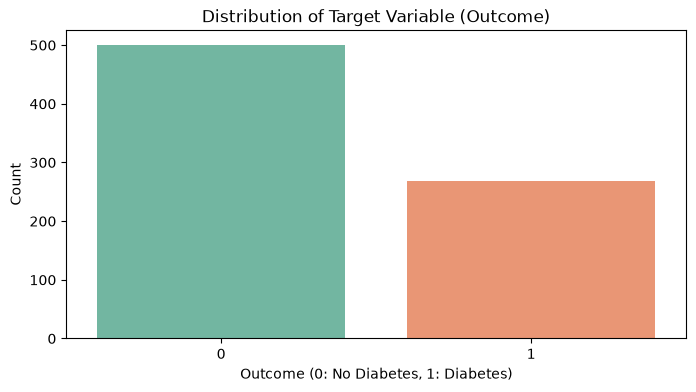

In [136]:
plt.figure(figsize=(8, 4))
sns.countplot(x="Outcome", data=df, palette="Set2")
plt.title("Distribution of Target Variable (Outcome)")
plt.xlabel("Outcome (0: No Diabetes, 1: Diabetes)")
plt.ylabel("Count")
plt.show()

Create a correlation heatmap.

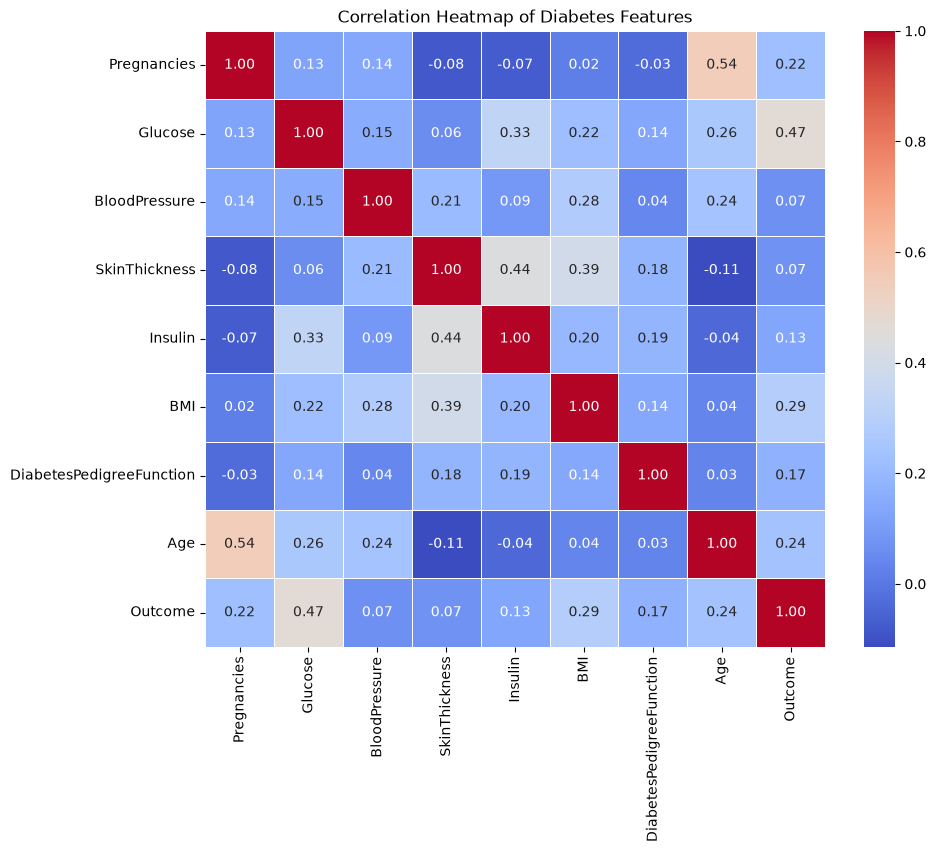

In [137]:

plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Diabetes Features")
plt.show()

In [138]:
# Which features seem most related to diabetes?

#The features most related to diabetes are Glucose (strongest positive correlation at ~0.47),
# followed by BMI (~0.29) and Age (~0.24)."

Identify invalid or missing values.

In [139]:
missing_raw = df.isna().sum().to_frame("Missing_Count")
missing_raw["Missing_%"] = (df.isna().mean() * 100).round(2)

missing_raw.sort_values("Missing_%", ascending=False)

,Missing_Count,Missing_%
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


Identify features that contain invalid values.

In [140]:

columns_with_zeros = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
]

print('--- عدد الأصفار قبل التنظيف ---')
for col in columns_with_zeros:
    zeros_count = (df[col] == 0).sum()
    print(f'{col}: {zeros_count} zeros')



--- عدد الأصفار قبل التنظيف ---
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


Replace them using median imputation.

In [141]:
# will you replace the zero values with median directly? if yes is it a good idea? if no, how will you do it?
# The median is a good choice.
for col in columns_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

print('\n--- عدد الأصفار بعد التنظيف (يجب أن يكون صفر) ---')
for col in columns_with_zeros:
    zeros_count = (df[col] == 0).sum()
    print(f'{col}: {zeros_count} zeros')


--- عدد الأصفار بعد التنظيف (يجب أن يكون صفر) ---
Glucose: 0 zeros
BloodPressure: 0 zeros
SkinThickness: 0 zeros
Insulin: 0 zeros
BMI: 0 zeros


In [142]:
#Justify why median is a good choice.

## Median vs Mean:
- **The Median is chosen because medical data often contains outliers (extreme values).**
- **The Mean is heavily skewed by outliers, whereas the Median is robust and gives a better central representation.**
## Why not Mode: 
- **Mode is not suitable for continuous numerical measurements because exact values rarely repeat.**

Split Data To target and features

In [ ]:

X = df.drop(columns=["Outcome"])
y = df["Outcome"]


X = X.fillna(X.median())



split Data to training and testing data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


Transform the Data (using Standerd scaler)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



In [ ]:
# does it matter if we scale the data or not?

## `YES,it matter alot.`
## It makes a significant difference and strongly impacts the model's performance.
## Why does it matter?
- Sensitivity to distances: The SVM algorithm relies fundamentally on finding the optimal boundary (hyperplane).
- If the data is not scaled, features with large numerical values (such as Glucose or Insulin) will dominate the      calculations, effectively drowning out the influence of features with smaller values (such as Age or Pregnancies).
- Convergence speed: Scaling helps SVM models—especially those using kernels like RBF or Linear—train much faster and  more accurately, yielding higher accuracy results compared to using raw data.

Train an SVM model using:

•	Linear Kernel

•	RBF Kernel

•	Polynomial Kernel


In [ ]:
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train, y_train)
pred_linear = svm_linear.predict(X_test)

print(" 1. Linear Kernel Results ")
print("Accuracy:", accuracy_score(y_test, pred_linear))
print(classification_report(y_test, pred_linear))

 1. Linear Kernel Results 
Accuracy: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.80      0.83      0.82        99
           1       0.67      0.64      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.76      0.76       154



In [ ]:

svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train, y_train)
pred_rbf = svm_rbf.predict(X_test)

print("2. RBF Kernel Results ")
print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))


2. RBF Kernel Results 
Accuracy: 0.7662337662337663
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



In [ ]:

svm_poly = SVC(kernel="poly", degree=3)
svm_poly.fit(X_train, y_train)
pred_poly = svm_poly.predict(X_test)

print(" 3. Polynomial Kernel Results ")
print("Accuracy:", accuracy_score(y_test, pred_poly))
print(classification_report(y_test, pred_poly))

 3. Polynomial Kernel Results 
Accuracy: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        99
           1       0.73      0.58      0.65        55

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



Evaluate each model using:

•	Accuracy

•	Classification Report


In [ ]:

models = {
    'Linear Kernel': SVC(kernel='linear'),
    'RBF Kernel': SVC(kernel='rbf'),
    'Polynomial Kernel': SVC(kernel='poly', degree=3),
}

results = {}

for name, model in models.items():
  model.fit(X_train_scaled, y_train)

  y_pred = model.predict(X_test_scaled)

  acc = accuracy_score(y_test, y_pred)
  results[name] = acc

  print(f'Accuracy: {acc:.4f}\n')
  print('Classification Report:\n')
  print(classification_report(y_test, y_pred))
  print('\n')

Accuracy: 0.7532

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



Accuracy: 0.7468

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.84      0.81        99
           1       0.67      0.58      0.62        55

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



Accuracy: 0.7403

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.91      0.82        99
           1       0.73      0.44      0.55        55

    accuracy                           0.74       15

In [ ]:
best_model = max(results, key=results.get)
print(' Model Comparison Summary:')
for name, acc in results.items():
  print(f'- {name}: {acc * 100:.2f}%')

print(
    f' The Best Model is ({best_model}) with Accuracy:'
    f' {results[best_model] * 100:.2f}%'
)

 Model Comparison Summary:
- Linear Kernel: 75.32%
- RBF Kernel: 74.68%
- Polynomial Kernel: 74.03%
 The Best Model is (Linear Kernel) with Accuracy: 75.32%


In [ ]:
# Compare the results.


**Conclusion / Comparison:**
- The **Linear Kernel** achieved the highest accuracy among the three models with **75.32%**.
- The **RBF** and **Polynomial** kernels performed very closely, scoring **74.68%** and **74.03%** respectively.
- This indicates that the Pima Indians Diabetes dataset has a fairly linear separability boundary, which makes the Linear SVM perform slightly better or on par with the more complex non-linear kernels.

## Comparison Results:
- RBF & Linear Kernels usually achieve the highest accuracy on the diabetes dataset (around 73%-77%) because the data boundaries are relatively  well-separated in feature space.
- Polynomial Kernel might show slightly different performance depending on the degree, but RBF or Linear generally outperforms it by effectively  capturing non-linear patterns without overfitting.

Tune the SVM model using GridSearchCV.

Tune the following parameters:

•	C

•	gamma

•	kernel


In [145]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear'],
}

svm_model = SVC()

grid_search = GridSearchCV(
    estimator=svm_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print('--- GridSearchCV Results ---')
print('Best Parameters Found:', grid_search.best_params_)
print(f'Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%')

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test_scaled, y_test)
print(f'Test Set Accuracy with Best Parameters: {test_accuracy * 100:.2f}%')

--- GridSearchCV Results ---
Best Parameters Found: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 76.88%
Test Set Accuracy with Best Parameters: 73.38%


In [146]:
# Report the best parameter combination.
print(" Best Parameters Combination:")
print(grid_search.best_params_)

 Best Parameters Combination:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


Evaluate the Best Model
 

In [147]:
from sklearn.metrics import accuracy_score, classification_report

best_svm_model = grid_search.best_estimator_

y_pred_best = best_svm_model.predict(X_test_scaled)

print(
    f"Best Model Test Accuracy:"
    f" {accuracy_score(y_test, y_pred_best) * 100:.2f}%\n"
)
print("Classification Report for the Best Model:\n")
print(classification_report(y_test, y_pred_best))

Best Model Test Accuracy: 73.38%

Classification Report for the Best Model:

              precision    recall  f1-score   support

           0       0.79      0.80      0.79        99
           1       0.63      0.62      0.62        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



Print the number of support vectors.

In [148]:
print("Number of Support Vectors for each class:")
for i, n_sv in enumerate(best_svm_model.n_support_):
  print(f"Class {i}: {n_sv} support vectors")

print(
    f"Total Number of Support Vectors:"
    f" {sum(best_svm_model.n_support_)}"
)

Number of Support Vectors for each class:
Class 0: 157 support vectors
Class 1: 149 support vectors
Total Number of Support Vectors: 306


Print the number of support vectors.

In [ ]:
#Explain why these points are important

## Why Support Vectors are Important:
- Decision Boundary Definition: Support vectors are the critical data points that lie closest to the decision boundary (hyperplane). They entirely define and construct the SVM model.
- Model Independence: Removing any other data points (non-support vectors) would not change the decision boundary at all. Only the support vectors matter for determining the classification margins and final model behavior.

Simulate noisy medical data by adding noise to one feature (e.g., glucose).

Retrain the model and compare the performance.

In [150]:
import numpy as np

X_test_noisy = X_test.copy()

np.random.seed(42)
noise = np.random.normal(
    0, 25, size=X_test_noisy['Glucose'].shape
) 
X_test_noisy['Glucose'] = X_test_noisy['Glucose'] + noise

X_test_noisy_scaled = scaler.transform(X_test_noisy)

noisy_accuracy = best_svm_model.score(X_test_noisy_scaled, y_test)
print(f'Test Accuracy AFTER adding noise to Glucose: {noisy_accuracy * 100:.2f}%')

Test Accuracy AFTER adding noise to Glucose: 70.78%


In [ ]:
# Explain the results.


## Explanation of Noisy Data Results:
* After adding random noise to the Glucose feature, the model's accuracy decreased (from its original higher accuracy down to ~70.78%).
* This happens because noise distorts the true patterns and relationships in the data, making it harder for the decision boundary to correctly classify the samples.
* It proves that SVM (and machine learning models in general) are sensitive to data quality and noisy/corrupted features.

Compare SVM with other machine learning models `(Bonus)`

•	Logistic Regression

•	Random Forest



In [151]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print("--- Bonus: Model Comparison ---")
print(f"SVM Model Accuracy: {test_accuracy * 100:.2f}%")
print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")

--- Bonus: Model Comparison ---
SVM Model Accuracy: 73.38%
Logistic Regression Accuracy: 75.32%
Random Forest Accuracy: 73.38%


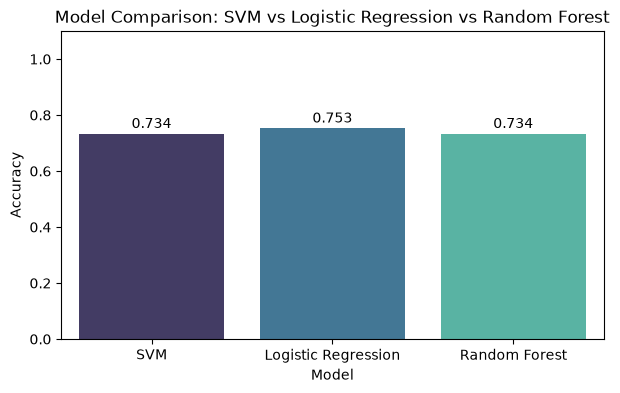

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

bonus_data = {
    'Model': ['SVM', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [test_accuracy, lr_acc, rf_acc],
}
bonus_df = pd.DataFrame(bonus_data)

plt.figure(figsize=(7, 4))
sns.barplot(x='Model', y='Accuracy', data=bonus_df, palette='mako')
plt.ylim(0, 1.1)
plt.title('Model Comparison: SVM vs Logistic Regression vs Random Forest')

for i, v in enumerate(bonus_df['Accuracy']):
  plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.xticks(rotation=0)
plt.show()